# Karan Dattatray Tormal

## Data Science – Task 1
### Iris Flower Classification

**Objective:** Train a machine learning classification model to identify the species of an iris flower
(Setosa, Versicolor, Virginica) from its physical measurements.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

sns.set_style("whitegrid")


## 2. Load Dataset

In [2]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["target"] = iris.target

df["species"] = df["target"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

print("First 5 Rows:")
print(df.head())


First 5 Rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  Setosa  
1       0  Setosa  
2       0  Setosa  
3       0  Setosa  
4       0  Setosa  


## 3. Exploratory Data Analysis (EDA)

In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

print("\nSpecies Count:")
print(df["species"].value_counts())


Dataset Shape:
(150, 6)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 8.4 KB

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Statistical Summary:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          

**Observations:**
- 150 rows, 4 numeric features + target/species columns, no missing values.
- The three species are perfectly balanced (50 rows each), so accuracy is a fair metric for evaluation.

## 4. Data Visualization

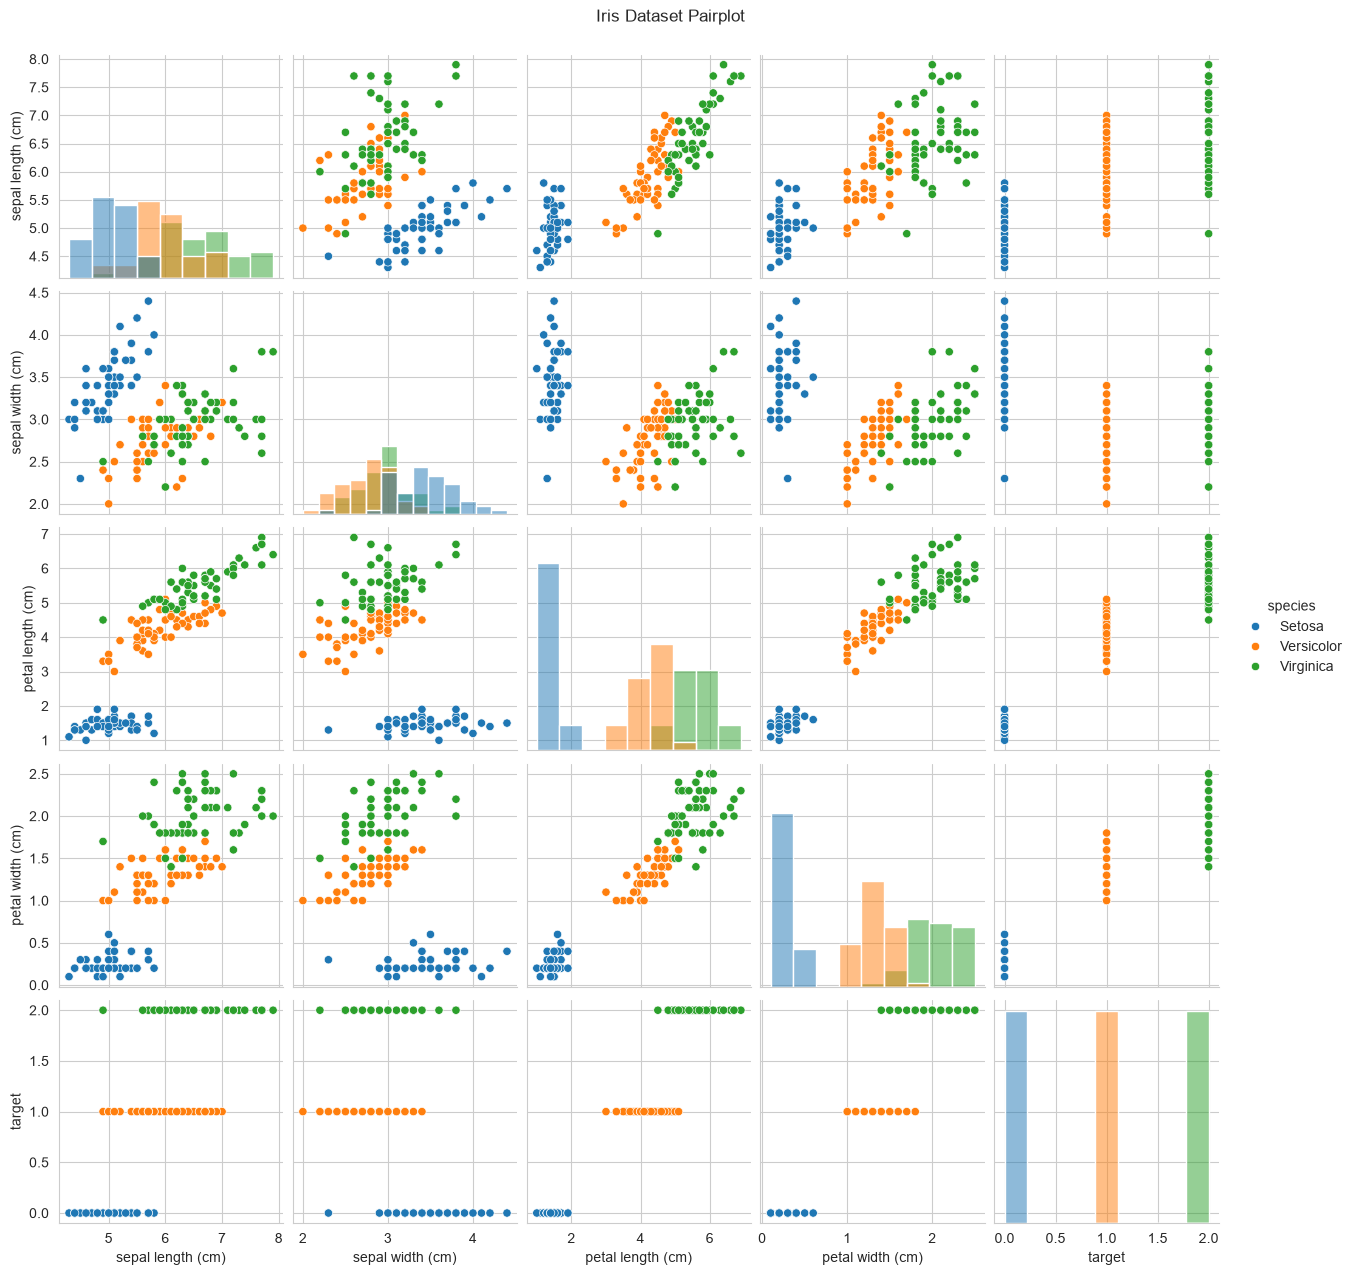

In [4]:
# Pairplot - feature distributions and pairwise relationships by species
sns.pairplot(df, hue="species", diag_kind="hist")
plt.suptitle("Iris Dataset Pairplot", y=1.02)
plt.show()


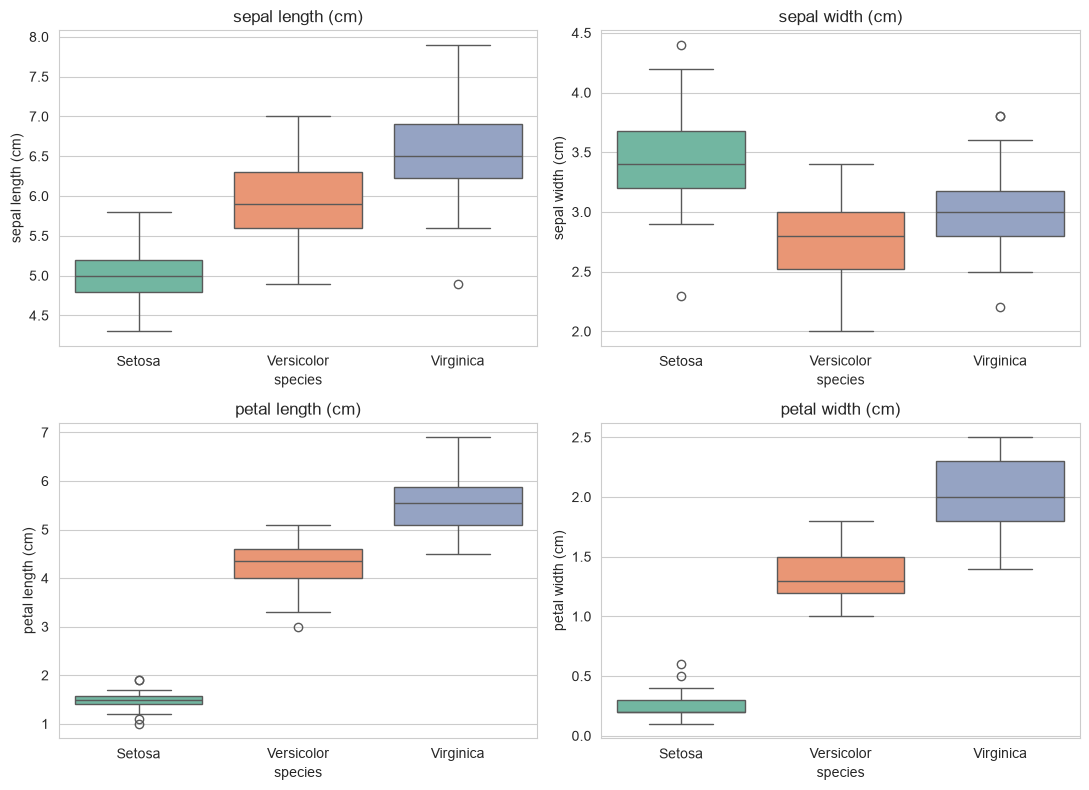

In [5]:
# Boxplot for each feature, split by species
features = [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)"
]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    sns.boxplot(data=df, x="species", y=feature, hue="species", legend=False, ax=ax, palette="Set2")
    ax.set_title(feature)

plt.tight_layout()
plt.show()


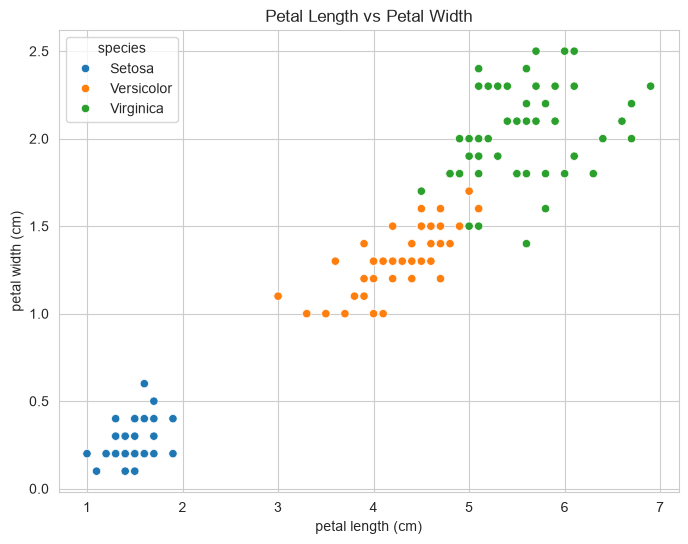

In [6]:
# Petal Length vs Petal Width
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species"
)

plt.title("Petal Length vs Petal Width")
plt.show()


## 5. Feature Selection Discussion

In [7]:
# ANOVA F-test: higher F-score = feature separates the 3 species better
f_scores, p_values = f_classif(df[features], df["target"])

feature_scores = pd.DataFrame({
    "Feature": features,
    "F_score": f_scores,
    "p_value": p_values
}).sort_values("F_score", ascending=False).reset_index(drop=True)

print(feature_scores)


             Feature      F_score       p_value
0  petal length (cm)  1180.161182  2.856777e-91
1   petal width (cm)   960.007147  4.169446e-85
2  sepal length (cm)   119.264502  1.669669e-31
3   sepal width (cm)    49.160040  4.492017e-17


**Conclusion:** Petal length and petal width have the highest F-scores (and near-zero p-values),
confirming they are the most discriminative features — visible in the boxplots and scatterplot above,
where Setosa is fully separated and Versicolor/Virginica overlap only slightly on these two features.
Sepal length and sepal width are comparatively weaker discriminators. All four features are still
kept for modelling since they don't hurt performance on this small, clean dataset.

## 6. Prepare Data

In [8]:
X = df[features]
y = df["target"]


## 7. Train-Test Split (80/20)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (120, 4)
Testing Data Shape: (30, 4)


## 8. Feature Scaling

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 9. Model 1 - Logistic Regression

LOGISTIC REGRESSION
Accuracy: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



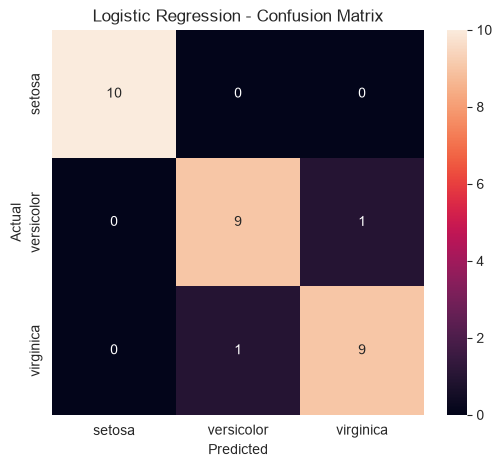

In [11]:
model_lr = LogisticRegression(max_iter=200)
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("====================================")
print("LOGISTIC REGRESSION")
print("====================================")
print("Accuracy:", accuracy_lr)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=iris.target_names))

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt="d", xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()


## 10. Model 2 - K-Nearest Neighbors

K-NEAREST NEIGHBORS
Accuracy: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



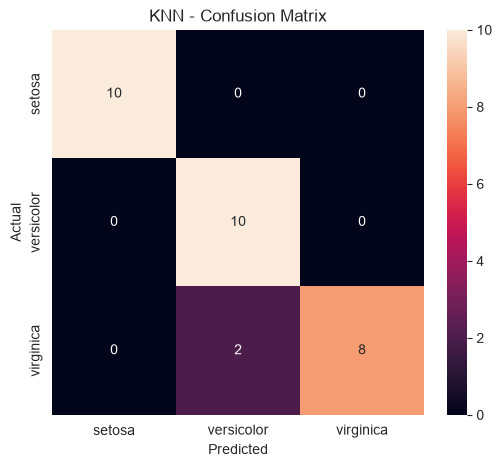

In [12]:
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)
y_pred_knn = model_knn.predict(X_test_scaled)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("====================================")
print("K-NEAREST NEIGHBORS")
print("====================================")
print("Accuracy:", accuracy_knn)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=iris.target_names))

cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt="d", xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN - Confusion Matrix")
plt.show()


## 11. Model 3 - Decision Tree

DECISION TREE
Accuracy: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



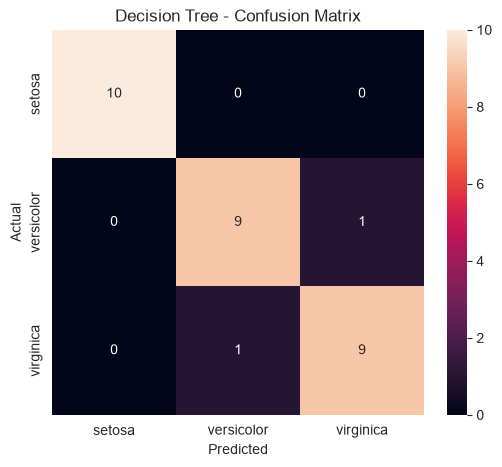

In [13]:
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("====================================")
print("DECISION TREE")
print("====================================")
print("Accuracy:", accuracy_dt)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=iris.target_names))

cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt="d", xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")
plt.show()


## 12. Model 4 - Random Forest

RANDOM FOREST
Accuracy: 0.9

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



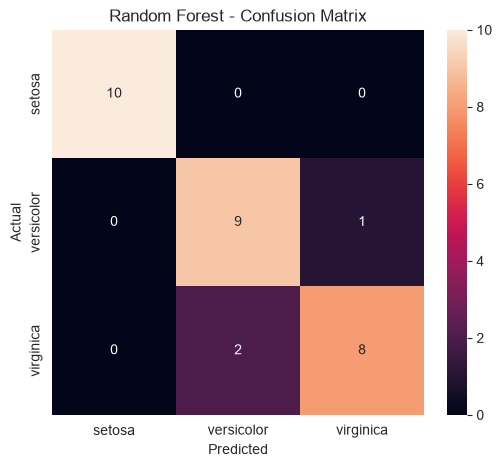

In [14]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("====================================")
print("RANDOM FOREST")
print("====================================")
print("Accuracy:", accuracy_rf)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=iris.target_names))

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()


## 13. Model Comparison

MODEL COMPARISON
                 Model  Accuracy
0  Logistic Regression  0.933333
1  K-Nearest Neighbors  0.933333
2        Decision Tree  0.933333
3        Random Forest  0.900000


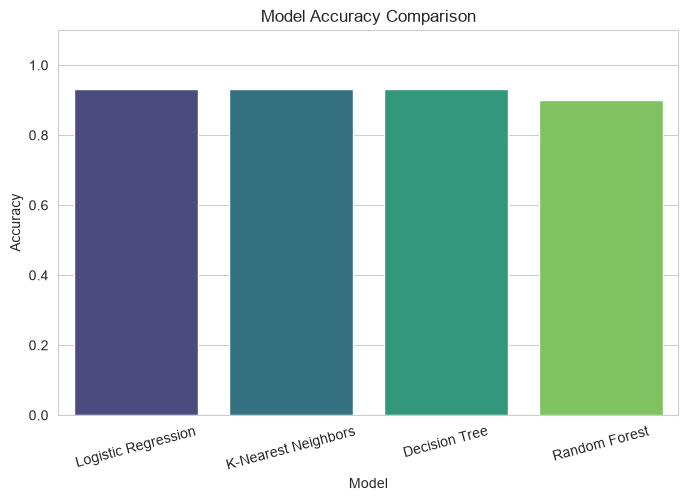

In [15]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_knn,
        accuracy_dt,
        accuracy_rf
    ]
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)

print("====================================")
print("MODEL COMPARISON")
print("====================================")
print(results)

plt.figure(figsize=(8, 5))
sns.barplot(data=results, x="Model", y="Accuracy", hue="Model", legend=False, palette="viridis")
plt.ylim(0, 1.1)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.show()


## 14. Best Model

In [16]:
best_model = results.iloc[0]["Model"]
best_accuracy = results.iloc[0]["Accuracy"]

print("====================================")
print("BEST MODEL")
print("====================================")
print("Best Model:", best_model)
print("Best Accuracy:", best_accuracy)


BEST MODEL
Best Model: Logistic Regression
Best Accuracy: 0.9333333333333333


## 15. Final Conclusion

In [17]:
print("====================================")
print("CONCLUSION")
print("====================================")

print(f'''
The Iris Flower Classification dataset was analyzed using
Exploratory Data Analysis and visualization techniques.

Four machine learning classification models were implemented:
1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree
4. Random Forest

All models were evaluated using accuracy, precision, recall,
F1-score and confusion matrix.

An ANOVA F-test confirmed that petal length and petal width
are the most discriminative features for distinguishing between
the three Iris species: Setosa, Versicolor and Virginica.

The best-performing model was: {best_model}
with an accuracy of: {best_accuracy:.4f}
''')


CONCLUSION

The Iris Flower Classification dataset was analyzed using
Exploratory Data Analysis and visualization techniques.

Four machine learning classification models were implemented:
1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree
4. Random Forest

All models were evaluated using accuracy, precision, recall,
F1-score and confusion matrix.

An ANOVA F-test confirmed that petal length and petal width
are the most discriminative features for distinguishing between
the three Iris species: Setosa, Versicolor and Virginica.

The best-performing model was: Logistic Regression
with an accuracy of: 0.9333

